# Misclassification Analysis: Finding Potentially Wrong Labels

This notebook compares predictions from V3 (hierarchical CNN) and V4 (hybrid CNN+GNN) models to identify sequences that may have incorrect labels.

**Strategy:**
1. Load both model checkpoints
2. Run inference on all sequences
3. Compare predictions:
   - **Both models agree with label** → Likely correct labels
   - **Both models disagree with label** → **Potentially wrong labels** (high confidence)
   - **One model agrees, one disagrees** → Ambiguous cases for review

In [1]:
# ============ Imports ============
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from collections import Counter
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if hasattr(torch.backends, 'mps'):
    print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.9.0
CUDA available: False
MPS available: True


In [ ]:
# ============ Configuration ============
FASTA_PATH = Path("../../data/vgp/all_vgp_tes.fa")
LABEL_PATH = Path("../../data/vgp/20251215-features-tpase")

# Model checkpoints
V3_CKPT_PATH = Path("rc_cnn_hierarchical_v3.pt")
V4_CKPT_PATH = Path("hybrid_v4_epoch39.pt")  # V4.0 checkpoint
V41_CKPT_PATH = Path("v4.1 cluster/hybrid_v4.1_epoch59.pt")  # V4.1 with 5-fold CV

# Check available checkpoints
print("Available checkpoints in current directory:")
for f in sorted(Path(".").glob("*.pt")):
    print(f"  {f.name}")
print("\nAvailable V4.1 checkpoints:")
for f in sorted(Path("v4.1 cluster").glob("*.pt")):
    print(f"  {f.name}")

print(f"\nV3 checkpoint: {V3_CKPT_PATH} - {'✓' if V3_CKPT_PATH.exists() else '✗'}")
print(f"V4 checkpoint: {V4_CKPT_PATH} - {'✓' if V4_CKPT_PATH.exists() else '✗'}")
print(f"V4.1 checkpoint: {V41_CKPT_PATH} - {'✓' if V41_CKPT_PATH.exists() else '✗'}")
print(f"FASTA file: {FASTA_PATH} - {'✓' if FASTA_PATH.exists() else '✗'}")
print(f"Label file: {LABEL_PATH} - {'✓' if LABEL_PATH.exists() else '✗'}")

def resolve_device(requested=None):
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"\nUsing device: {DEVICE}")

Available checkpoints in current directory:
  hybrid_v4_epoch39.pt
  hybrid_v5_epoch27.pt
  improved_rc_cnn_best.pt
  rc_cnn_hierarchical_v3.pt
  rc_cnn_tpase_v2.pt
  rc_cnn_tpase_v2_v1.pt
  rc_cnn_tpase_v2_v2.pt

V3 checkpoint: rc_cnn_hierarchical_v3.pt - ✓
V4 checkpoint: hybrid_v4_epoch39.pt - ✓
FASTA file: ../../data/vgp/all_vgp_tes.fa - ✓
Label file: ../../data/vgp/20251215-features-tpase - ✓

Using device: mps


In [7]:
# ============ Data Loading ============

def read_fasta(path):
    """Read FASTA file and return headers and sequences."""
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
    return headers, sequences


def load_hierarchical_labels(label_path):
    """Load labels for hierarchical classification."""
    label_path = Path(label_path)
    label_dict, binary_dict = {}, {}
    
    with label_path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            header = parts[0].lstrip('>')
            tag = parts[1]
            
            label_dict[header] = tag
            binary_dict[header] = 0 if tag == "None" else 1
    
    return label_dict, binary_dict


# Load data
print("Loading FASTA sequences...")
headers, sequences = read_fasta(FASTA_PATH)
print(f"Loaded {len(headers)} sequences")

print("\nLoading labels...")
label_dict, binary_dict = load_hierarchical_labels(LABEL_PATH)
print(f"Loaded {len(label_dict)} labels")

# Match
matched_h, matched_s, matched_tags = [], [], []
for h, s in zip(headers, sequences):
    if h in label_dict:
        matched_h.append(h)
        matched_s.append(s)
        matched_tags.append(label_dict[h])

print(f"\nMatched {len(matched_h)} sequences with labels")

# Show label distribution
tag_counts = Counter(matched_tags)
print(f"\nLabel distribution (top 15):")
for tag, count in tag_counts.most_common(15):
    print(f"  {tag}: {count}")

Loading FASTA sequences...
Loaded 135751 sequences

Loading labels...
Loaded 135751 labels

Matched 135751 sequences with labels

Label distribution (top 15):
  None: 125098
  DNA/hAT: 4899
  DNA/TcMar-Tc1: 1875
  DNA: 1530
  DNA/PIF-Harbinger: 790
  DNA/PiggyBac: 565
  DNA/Academ-1: 416
  DNA/CMC: 180
  DNA/Sola-2: 94
  DNA/Kolobok: 86
  DNA/P: 77
  DNA/Sola-1: 43
  DNA/PIF-ISL2EU: 38
  DNA/MULE-MuDR: 23
  DNA/Crypton-V: 19


In [ ]:
# ============ Load Checkpoints and Inspect ============

print("Loading V3 checkpoint...")
v3_ckpt = torch.load(V3_CKPT_PATH, map_location="cpu", weights_only=False)
print(f"V3 keys: {list(v3_ckpt.keys())}")

print("\nLoading V4 checkpoint...")
v4_ckpt = torch.load(V4_CKPT_PATH, map_location="cpu", weights_only=False)
print(f"V4 keys: {list(v4_ckpt.keys())}")

print("\nLoading V4.1 checkpoint...")
v41_ckpt = torch.load(V41_CKPT_PATH, map_location="cpu", weights_only=False)
print(f"V4.1 keys: {list(v41_ckpt.keys())}")
print(f"V4.1 epoch: {v41_ckpt.get('epoch', 'N/A')}, score: {v41_ckpt.get('score', 'N/A'):.4f}")

# Extract architecture info
if "arch" in v3_ckpt:
    print(f"\nV3 architecture: {v3_ckpt['arch']}")
if "arch" in v4_ckpt:
    print(f"\nV4 architecture: {v4_ckpt['arch']}")
if "arch" in v41_ckpt:
    print(f"\nV4.1 architecture: {v41_ckpt['arch']}")

# Extract class mappings
v3_sf_names = v3_ckpt.get("superfamily_names", [])
v4_sf_names = v4_ckpt.get("superfamily_names", [])
v41_sf_names = v41_ckpt.get("superfamily_names", [])

print(f"\nV3 superfamilies ({len(v3_sf_names)}): {v3_sf_names}")
print(f"V4 superfamilies ({len(v4_sf_names)}): {v4_sf_names}")
print(f"V4.1 superfamilies ({len(v41_sf_names)}): {v41_sf_names}")

Loading V3 checkpoint...
V3 keys: ['model_state_dict', 'superfamily_names', 'superfamily_to_id', 'arch', 'best_epoch']

Loading V4 checkpoint...
V4 keys: ['model_state_dict', 'superfamily_names', 'superfamily_to_id', 'arch', 'history', 'epoch', 'score']

V3 architecture: {'width': 128, 'motif_kernels': (7, 15, 21), 'context_kernel': 9, 'context_dilations': (1, 2, 4, 8), 'rc_mode': 'early', 'num_superfamilies': 7}

V4 architecture: {'cnn_width': 128, 'motif_kernels': (7, 15, 21), 'context_dilations': (1, 2, 4, 8), 'rc_mode': 'late', 'gnn_in_dim': 2049, 'gnn_hidden': 128, 'gnn_layers': 3, 'fusion_dim': 256, 'num_heads': 4, 'num_superfamilies': 7, 'fixed_length': 5000}

V3 superfamilies (7): ['DNA', 'DNA/Academ-1', 'DNA/CMC', 'DNA/PIF-Harbinger', 'DNA/PiggyBac', 'DNA/TcMar-Tc1', 'DNA/hAT']
V4 superfamilies (7): ['DNA', 'DNA/Academ-1', 'DNA/CMC', 'DNA/PIF-Harbinger', 'DNA/PiggyBac', 'DNA/TcMar-Tc1', 'DNA/hAT']


In [9]:
# ============ Model Architecture (V3 - CNN Only) ============

ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTNacgtn", [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]):
    ENCODE[ch] = idx

REV_COMP = torch.tensor([3, 2, 1, 0, 4], dtype=torch.long)


class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation)
        self.bn = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1)

    def forward(self, x):
        y = self.conv(x)
        y = F.gelu(self.bn(y))
        y = self.drop(y)
        return y + self.proj(x)


class MaskedMaxPool1d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x, mask):
        if mask is not None:
            m = mask.unsqueeze(1).float()
            x = x * m + (~mask.unsqueeze(1)) * (-1e9)
        x_p = F.max_pool1d(x, self.kernel_size, self.stride)
        if mask is None:
            return x_p, None
        m_p = F.max_pool1d(mask.float().unsqueeze(1), self.kernel_size, self.stride).squeeze(1) > 0
        return x_p, m_p


def masked_avg_pool(z, mask):
    if mask is None:
        return z.mean(-1)
    m = mask.unsqueeze(1).float()
    return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)


print("V3 model building blocks defined.")

V3 model building blocks defined.


In [16]:
# ============ RC Early Fusion Layer ============

class RCFirstConv1d(nn.Module):
    """
    RC-invariant first convolution layer.
    Computes max(conv(x), conv(RC(x))) for early RC fusion.
    """
    def __init__(self, out_channels, kernel_size=15, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        y1 = self.conv(x)
        
        # Reverse complement
        x_rc = x.flip(-1).index_select(1, REV_COMP.to(x.device))
        y2 = self.conv(x_rc).flip(-1)
        
        # Take element-wise max for RC invariance
        y = torch.max(y1, y2)
        y = self.batch_norm(y)
        y = F.gelu(y)
        y = self.dropout(y)
        
        return y


# ============ V3 Model (Hierarchical CNN) ============

class HierarchicalTEClassifierV3(nn.Module):
    """V3: Hierarchical CNN classifier with boundary head."""
    def __init__(
        self,
        num_superfamilies: int,
        width: int = 128,
        motif_kernels: Tuple = (7, 15, 21),
        context_dilations: Tuple = (1, 2, 4, 8),
        dropout: float = 0.15,
        rc_mode: str = "early"  # V3 uses early by default
    ):
        super().__init__()
        self.rc_mode = rc_mode
        self.num_superfamilies = num_superfamilies
        
        # Motif detection - use RCFirstConv1d for early mode
        if rc_mode == "early":
            self.motif_convs = nn.ModuleList([
                RCFirstConv1d(width, kernel_size=k, dropout=dropout)
                for k in motif_kernels
            ])
        else:
            self.motif_convs = nn.ModuleList([
                nn.Sequential(
                    nn.Conv1d(5, width, kernel_size=k, padding=k // 2, bias=True),
                    nn.BatchNorm1d(width),
                    nn.GELU(),
                    nn.Dropout(dropout)
                )
                for k in motif_kernels
            ])
        
        in_ch = width * len(motif_kernels)
        self.mix = nn.Sequential(
            nn.Conv1d(in_ch, width, kernel_size=1, bias=True),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        self.context_blocks = nn.ModuleList([
            ConvBlock(width, width, kernel_size=9, dilation=d, dropout=dropout)
            for d in context_dilations
        ])
        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)
        
        # Binary head
        self.binary_head = nn.Sequential(
            nn.Linear(width, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
        
        # Superfamily head
        self.superfamily_head = nn.Sequential(
            nn.Linear(width, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_superfamilies)
        )
        
        # Boundary prediction head (auxiliary)
        self.boundary_head = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 3),
            nn.Sigmoid()
        )

    def encode(self, x, mask):
        feats = [conv(x) for conv in self.motif_convs]
        z = torch.cat(feats, dim=1)
        z = self.mix(z)
        
        m = mask
        for block in self.context_blocks:
            z = block(z)
            z, m = self.pool(z, m)
        
        return masked_avg_pool(z, m)

    @staticmethod
    def rc_transform(x, mask):
        x_rc = x.index_select(1, REV_COMP.to(x.device)).flip(-1)
        mask_rc = None if mask is None else mask.flip(-1)
        return x_rc, mask_rc

    def forward(self, x, mask):
        if self.rc_mode == "late":
            f = self.encode(x, mask)
            x_rc, mask_rc = self.rc_transform(x, mask)
            r = self.encode(x_rc, mask_rc)
            embed = 0.5 * (f + r)
        else:
            embed = self.encode(x, mask)
        
        binary_logits = self.binary_head(embed)
        sf_logits = self.superfamily_head(embed)
        boundary_pred = self.boundary_head(embed)
        
        return binary_logits, sf_logits, boundary_pred


print("RCFirstConv1d and V3 model classes defined (with boundary_head, rc_mode=early).")

RCFirstConv1d and V3 model classes defined (with boundary_head, rc_mode=early).


In [11]:
# ============ K-mer Featurizer for V4 ============

_ASCII_MAP = np.full(256, 4, dtype=np.uint8)
for ch, val in [("A", 0), ("C", 1), ("G", 2), ("T", 3), ("a", 0), ("c", 1), ("g", 2), ("t", 3)]:
    _ASCII_MAP[ord(ch)] = val

_COMP = np.array([3, 2, 1, 0], dtype=np.uint8)


def kmer_code_forward(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4:
        code = (code << 2) | int(v)
    return code


def kmer_code_rc(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4[::-1]:
        code = (code << 2) | int(_COMP[v])
    return code


def canonical_kmer_code(arr4: np.ndarray) -> int:
    c1 = kmer_code_forward(arr4)
    c2 = kmer_code_rc(arr4)
    return c1 if c1 < c2 else c2


def hash_u32(x: int, dim: int) -> int:
    z = (x * 0x9E3779B97F4A7C15) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 33)
    z = (z * 0xC2B2AE3D27D4EB4F) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 29)
    return int(z % dim)


@dataclass
class KmerWindowFeaturizer:
    k: int = 7
    dim: int = 2048
    window: int = 512
    stride: int = 256
    add_pos: bool = True
    l2_normalize: bool = True

    def featurize_sequence(self, seq: str) -> Tuple[np.ndarray, np.ndarray]:
        arr = _ASCII_MAP[np.frombuffer(seq.encode("ascii", "ignore"), dtype=np.uint8)]
        L = int(arr.size)
        
        if L == 0:
            X = np.zeros((1, self.dim + (1 if self.add_pos else 0)), dtype=np.float32)
            return X, np.array([0], dtype=np.int64)

        if L <= self.window:
            starts = np.array([0], dtype=np.int64)
        else:
            starts = np.arange(0, L - self.window + 1, self.stride, dtype=np.int64)
            if starts.size == 0:
                starts = np.array([0], dtype=np.int64)

        out_dim = self.dim + (1 if self.add_pos else 0)
        X = np.zeros((starts.size, out_dim), dtype=np.float32)

        for wi, st in enumerate(starts):
            en = min(st + self.window, L)
            sub = arr[st:en]
            counts = np.zeros(self.dim, dtype=np.float32)
            total = 0

            k = self.k
            if sub.size >= k:
                for i in range(0, sub.size - k + 1):
                    kmer = sub[i:i + k]
                    if np.any(kmer == 4):
                        continue
                    code = canonical_kmer_code(kmer)
                    j = hash_u32(code, self.dim)
                    counts[j] += 1.0
                    total += 1

            if total > 0:
                counts /= float(total)

            if self.l2_normalize:
                nrm = np.linalg.norm(counts)
                if nrm > 0:
                    counts /= nrm

            if self.add_pos:
                center = (st + en) / 2.0
                pos = center / max(1.0, float(L))
                X[wi, :-1] = counts
                X[wi, -1] = pos
            else:
                X[wi, :] = counts

        return X, starts


def build_chain_edge_index(n: int, undirected: bool = True, self_loops: bool = True) -> torch.Tensor:
    edges = []
    if n > 1:
        src = np.arange(n - 1, dtype=np.int64)
        dst = np.arange(1, n, dtype=np.int64)
        edges.append((src, dst))
        if undirected:
            edges.append((dst, src))
    if self_loops:
        idx = np.arange(n, dtype=np.int64)
        edges.append((idx, idx))
    if not edges:
        ei = np.zeros((2, 0), dtype=np.int64)
    else:
        s = np.concatenate([e[0] for e in edges])
        d = np.concatenate([e[1] for e in edges])
        ei = np.stack([s, d], axis=0)
    return torch.from_numpy(ei)


print("K-mer featurizer defined.")

K-mer featurizer defined.


In [12]:
# ============ V4 Model Components (GNN Tower) ============

def scatter_mean(x: torch.Tensor, idx: torch.Tensor, dim_size: int) -> torch.Tensor:
    out = torch.zeros((dim_size, x.size(1)), device=x.device, dtype=x.dtype)
    out.index_add_(0, idx, x)
    cnt = torch.bincount(idx, minlength=dim_size).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
    return out / cnt


class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.1):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index[0], edge_index[1]
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, x[src])
        deg = torch.bincount(dst, minlength=x.size(0)).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
        agg = agg / deg
        h = self.lin_self(x) + self.lin_neigh(agg)
        h = F.relu(h)
        return self.dropout(h)


class GNNTower(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 128, n_layers: int = 3, dropout: float = 0.1):
        super().__init__()
        self.out_dim = hidden
        
        layers = []
        d = in_dim
        for _ in range(n_layers):
            layers.append(GraphSAGELayer(d, hidden, dropout=dropout))
            d = hidden
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch_vec: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x, edge_index)
        
        B = int(batch_vec.max().item()) + 1 if batch_vec.numel() else 0
        return scatter_mean(x, batch_vec, dim_size=B)


print("GNN tower defined.")

GNN tower defined.


In [13]:
# ============ V4 Model Components (CNN Tower + Fusion) ============

class CNNTower(nn.Module):
    def __init__(
        self,
        width: int = 128,
        motif_kernels: Tuple = (7, 15, 21),
        context_dilations: Tuple = (1, 2, 4, 8),
        dropout: float = 0.15,
        rc_mode: str = "late"
    ):
        super().__init__()
        self.rc_mode = rc_mode
        self.out_dim = width
        
        self.motif_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(5, width, kernel_size=k, padding=k // 2),
                nn.BatchNorm1d(width),
                nn.GELU(),
                nn.Dropout(dropout)
            )
            for k in motif_kernels
        ])
        
        in_ch = width * len(motif_kernels)
        self.mix = nn.Sequential(
            nn.Conv1d(in_ch, width, kernel_size=1),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        self.context_blocks = nn.ModuleList([
            ConvBlock(width, width, kernel_size=9, dilation=d, dropout=dropout)
            for d in context_dilations
        ])
        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)

    def encode(self, x, mask):
        feats = [conv(x) for conv in self.motif_convs]
        z = torch.cat(feats, dim=1)
        z = self.mix(z)
        
        m = mask
        for block in self.context_blocks:
            z = block(z)
            z, m = self.pool(z, m)
        
        return masked_avg_pool(z, m)

    def forward(self, x, mask):
        if self.rc_mode == "late":
            f = self.encode(x, mask)
            x_rc = x.index_select(1, REV_COMP.to(x.device)).flip(-1)
            mask_rc = mask.flip(-1) if mask is not None else None
            r = self.encode(x_rc, mask_rc)
            return 0.5 * (f + r)
        else:
            return self.encode(x, mask)


class CrossModalAttentionFusion(nn.Module):
    def __init__(self, cnn_dim=128, gnn_dim=128, fusion_dim=256, num_heads=4, dropout=0.2):
        super().__init__()
        self.fusion_dim = fusion_dim
        
        self.cnn_proj = nn.Linear(cnn_dim, fusion_dim)
        self.gnn_proj = nn.Linear(gnn_dim, fusion_dim)
        
        self.ln1 = nn.LayerNorm(fusion_dim)
        self.ln2 = nn.LayerNorm(fusion_dim)
        
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, 2),
            nn.Softmax(dim=-1)
        )
        
        self.out_proj = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, cnn_embed, gnn_embed):
        c = self.ln1(self.cnn_proj(cnn_embed))
        g = self.ln2(self.gnn_proj(gnn_embed))
        
        combined = torch.stack([c, g], dim=1)
        attn_out, _ = self.cross_attn(combined, combined, combined)
        
        c_attn = attn_out[:, 0]
        g_attn = attn_out[:, 1]
        
        gate_weights = self.gate(torch.cat([c_attn, g_attn], dim=-1))
        fused = gate_weights[:, 0:1] * c_attn + gate_weights[:, 1:2] * g_attn
        
        return self.out_proj(fused), gate_weights


print("CNN tower and fusion module defined.")

CNN tower and fusion module defined.


In [14]:
# ============ V4 Complete Model ============

class HybridTEClassifierV4(nn.Module):
    def __init__(
        self,
        num_superfamilies: int,
        cnn_width: int = 128,
        motif_kernels: Tuple = (7, 15, 21),
        context_dilations: Tuple = (1, 2, 4, 8),
        rc_mode: str = "late",
        gnn_in_dim: int = 2049,
        gnn_hidden: int = 128,
        gnn_layers: int = 3,
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.15
    ):
        super().__init__()
        self.num_superfamilies = num_superfamilies
        
        self.cnn_tower = CNNTower(
            width=cnn_width, motif_kernels=motif_kernels,
            context_dilations=context_dilations, dropout=dropout, rc_mode=rc_mode
        )
        
        self.gnn_tower = GNNTower(
            in_dim=gnn_in_dim, hidden=gnn_hidden, n_layers=gnn_layers, dropout=dropout
        )
        
        self.fusion = CrossModalAttentionFusion(
            cnn_dim=cnn_width, gnn_dim=gnn_hidden,
            fusion_dim=fusion_dim, num_heads=num_heads, dropout=dropout
        )
        
        self.binary_head = nn.Sequential(
            nn.Linear(fusion_dim, 128), nn.GELU(), nn.Dropout(0.2), nn.Linear(128, 2)
        )
        
        self.superfamily_head = nn.Sequential(
            nn.Linear(fusion_dim, 256), nn.GELU(), nn.Dropout(0.2), nn.Linear(256, num_superfamilies)
        )

    def forward(self, x_cnn, mask, x_gnn, edge_index, batch_vec):
        cnn_embed = self.cnn_tower(x_cnn, mask)
        gnn_embed = self.gnn_tower(x_gnn, edge_index, batch_vec)
        
        fused, gate_weights = self.fusion(cnn_embed, gnn_embed)
        
        return self.binary_head(fused), self.superfamily_head(fused), gate_weights


print("V4 hybrid model class defined.")

V4 hybrid model class defined.


In [ ]:
# V4 Model
v4_model = HybridTEClassifierV4(
    num_superfamilies=v4_arch.get("num_superfamilies", len(v4_sf_names)),
    cnn_width=v4_arch.get("cnn_width", 128),
    motif_kernels=v4_arch.get("motif_kernels", (7, 15, 21)),
    context_dilations=v4_arch.get("context_dilations", (1, 2, 4, 8)),
    rc_mode=v4_arch.get("rc_mode", "late"),
    gnn_in_dim=v4_arch.get("gnn_in_dim", 2049),
    gnn_hidden=v4_arch.get("gnn_hidden", 128),
    gnn_layers=v4_arch.get("gnn_layers", 3),
    fusion_dim=v4_arch.get("fusion_dim", 256),
    num_heads=v4_arch.get("num_heads", 4),
)
v4_model.load_state_dict(v4_ckpt["model_state_dict"])
v4_model.to(DEVICE)
v4_model.eval()
print(f"V4 model loaded: {sum(p.numel() for p in v4_model.parameters()):,} params")

# V4.1 Model (same architecture as V4, weights from 5-fold CV training)
v41_arch = v41_ckpt.get("arch", {})
v41_model = HybridTEClassifierV4(
    num_superfamilies=v41_arch.get("num_superfamilies", len(v41_sf_names)),
    cnn_width=v41_arch.get("cnn_width", 128),
    motif_kernels=v41_arch.get("motif_kernels", (7, 15, 21)),
    context_dilations=v41_arch.get("context_dilations", (1, 2, 4, 8)),
    rc_mode=v41_arch.get("rc_mode", "late"),
    gnn_in_dim=v41_arch.get("gnn_in_dim", 2049),
    gnn_hidden=v41_arch.get("gnn_hidden", 128),
    gnn_layers=v41_arch.get("gnn_layers", 3),
    fusion_dim=v41_arch.get("fusion_dim", 256),
    num_heads=v41_arch.get("num_heads", 4),
)
v41_model.load_state_dict(v41_ckpt["model_state_dict"])
v41_model.to(DEVICE)
v41_model.eval()
print(f"V4.1 model loaded: {sum(p.numel() for p in v41_model.parameters()):,} params")

V3 model loaded: 729,612 params
V4 model loaded: 1,889,035 params


In [18]:
# ============ Build Class Mappings ============

# Use the class mapping from the checkpoints
v3_sf_to_id = v3_ckpt.get("superfamily_to_id", {t: i for i, t in enumerate(v3_sf_names)})
v4_sf_to_id = v4_ckpt.get("superfamily_to_id", {t: i for i, t in enumerate(v4_sf_names)})

# Common classes for comparison
common_classes = set(v3_sf_names) & set(v4_sf_names)
print(f"Common superfamilies between V3 and V4: {len(common_classes)}")
print(f"  V3 only: {set(v3_sf_names) - common_classes}")
print(f"  V4 only: {set(v4_sf_names) - common_classes}")

# Fixed length for CNN
FIXED_LENGTH = v4_arch.get("fixed_length", 5000)
print(f"\nFixed length for CNN: {FIXED_LENGTH}")

Common superfamilies between V3 and V4: 7
  V3 only: set()
  V4 only: set()

Fixed length for CNN: 5000


In [21]:
# ============ Inference Functions ============

def prepare_cnn_input(seq: str, fixed_length: int = FIXED_LENGTH):
    """Prepare one-hot input for CNN."""
    seq_bytes = seq.encode("ascii", "ignore")
    seq_idx = ENCODE[np.frombuffer(seq_bytes, dtype=np.uint8)]
    seq_len = len(seq)
    
    # Center placement
    if seq_len >= fixed_length:
        start = 0
        seq_idx = seq_idx[:fixed_length]
        actual_len = fixed_length
    else:
        start = (fixed_length - seq_len) // 2
        actual_len = seq_len
    
    X = torch.zeros((1, 5, fixed_length), dtype=torch.float32)
    mask = torch.zeros((1, fixed_length), dtype=torch.bool)
    
    idx = torch.from_numpy(seq_idx[:actual_len].astype(np.int64))
    pos = torch.arange(actual_len, dtype=torch.long) + start
    X[0, idx, pos] = 1.0
    mask[0, start:start + actual_len] = (idx != 4)
    
    return X, mask


# K-mer featurizer for V4
featurizer = KmerWindowFeaturizer(k=7, dim=2048, window=512, stride=256, add_pos=True, l2_normalize=True)


@torch.no_grad()
def run_v3_inference(model, seqs: List[str], batch_size: int = 32):
    """Run V3 model inference."""
    model.eval()
    all_bin_pred, all_sf_pred, all_bin_prob, all_sf_prob = [], [], [], []
    
    for i in tqdm(range(0, len(seqs), batch_size), desc="V3 inference"):
        batch_seqs = seqs[i:i+batch_size]
        
        Xs, masks = [], []
        for s in batch_seqs:
            X, m = prepare_cnn_input(s)
            Xs.append(X)
            masks.append(m)
        
        X = torch.cat(Xs, dim=0).to(DEVICE)
        mask = torch.cat(masks, dim=0).to(DEVICE)
        
        # V3 returns (binary_logits, sf_logits, boundary_pred)
        bin_logits, sf_logits, _ = model(X, mask)  # Ignore boundary prediction
        
        bin_prob = F.softmax(bin_logits, dim=-1)
        sf_prob = F.softmax(sf_logits, dim=-1)
        
        all_bin_pred.extend(bin_logits.argmax(dim=-1).cpu().numpy())
        all_sf_pred.extend(sf_logits.argmax(dim=-1).cpu().numpy())
        all_bin_prob.extend(bin_prob.cpu().numpy())
        all_sf_prob.extend(sf_prob.cpu().numpy())
    
    return np.array(all_bin_pred), np.array(all_sf_pred), np.array(all_bin_prob), np.array(all_sf_prob)


@torch.no_grad()
def run_v4_inference(model, seqs: List[str], batch_size: int = 16):
    """Run V4 hybrid model inference (CNN + GNN)."""
    model.eval()
    all_bin_pred, all_sf_pred, all_bin_prob, all_sf_prob = [], [], [], []
    
    for i in tqdm(range(0, len(seqs), batch_size), desc="V4 inference"):
        batch_seqs = seqs[i:i+batch_size]
        B = len(batch_seqs)
        
        # Prepare CNN inputs
        Xs, masks = [], []
        for s in batch_seqs:
            X, m = prepare_cnn_input(s)
            Xs.append(X)
            masks.append(m)
        
        X_cnn = torch.cat(Xs, dim=0).to(DEVICE)
        mask = torch.cat(masks, dim=0).to(DEVICE)
        
        # Prepare GNN inputs (k-mer graph)
        all_node_feats, all_edges, batch_vec_list = [], [], []
        node_offset = 0
        
        for bi, s in enumerate(batch_seqs):
            node_feats, _ = featurizer.featurize_sequence(s)
            n_nodes = node_feats.shape[0]
            edges = build_chain_edge_index(n_nodes, undirected=True, self_loops=True)
            
            all_node_feats.append(torch.from_numpy(node_feats))
            all_edges.append(edges + node_offset)
            batch_vec_list.extend([bi] * n_nodes)
            node_offset += n_nodes
        
        x_gnn = torch.cat(all_node_feats, dim=0).to(DEVICE)
        edge_index = torch.cat(all_edges, dim=1).to(DEVICE)
        batch_vec = torch.tensor(batch_vec_list, dtype=torch.long, device=DEVICE)
        
        # Forward pass
        bin_logits, sf_logits, _ = model(X_cnn, mask, x_gnn, edge_index, batch_vec)
        
        bin_prob = F.softmax(bin_logits, dim=-1)
        sf_prob = F.softmax(sf_logits, dim=-1)
        
        all_bin_pred.extend(bin_logits.argmax(dim=-1).cpu().numpy())
        all_sf_pred.extend(sf_logits.argmax(dim=-1).cpu().numpy())
        all_bin_prob.extend(bin_prob.cpu().numpy())
        all_sf_prob.extend(sf_prob.cpu().numpy())
    
    return np.array(all_bin_pred), np.array(all_sf_pred), np.array(all_bin_prob), np.array(all_sf_prob)


print("Inference functions defined (V3 and V4).")

Inference functions defined (V3 and V4).


In [ ]:
# ============ Run Inference on All Sequences ============

print("Running V3 inference...")
v3_bin_pred, v3_sf_pred, v3_bin_prob, v3_sf_prob = run_v3_inference(v3_model, matched_s, batch_size=32)

print("\nRunning V4 inference...")
v4_bin_pred, v4_sf_pred, v4_bin_prob, v4_sf_prob = run_v4_inference(v4_model, matched_s, batch_size=16)

print("\nRunning V4.1 inference...")
v41_bin_pred, v41_sf_pred, v41_bin_prob, v41_sf_prob = run_v4_inference(v41_model, matched_s, batch_size=16)

print(f"\nInference complete!")
print(f"V3: {len(v3_bin_pred)} predictions")
print(f"V4: {len(v4_bin_pred)} predictions")
print(f"V4.1: {len(v41_bin_pred)} predictions")

Running V3 inference...


V3 inference:   0%|          | 0/4243 [00:00<?, ?it/s]


Running V4 inference...


V4 inference:   0%|          | 0/8485 [00:00<?, ?it/s]

In [ ]:
# ============ Build Results DataFrame ============

# Map predictions back to superfamily names
v3_sf_pred_names = [v3_sf_names[i] if 0 <= i < len(v3_sf_names) else "Unknown" for i in v3_sf_pred]
v4_sf_pred_names = [v4_sf_names[i] if 0 <= i < len(v4_sf_names) else "Unknown" for i in v4_sf_pred]
v41_sf_pred_names = [v41_sf_names[i] if 0 <= i < len(v41_sf_names) else "Unknown" for i in v41_sf_pred]

# Create DataFrame
df = pd.DataFrame({
    "header": matched_h,
    "true_label": matched_tags,
    "true_binary": [0 if t == "None" else 1 for t in matched_tags],
    "v3_bin_pred": v3_bin_pred,
    "v3_bin_conf": v3_bin_prob.max(axis=1),
    "v3_sf_pred": v3_sf_pred_names,
    "v3_sf_conf": v3_sf_prob.max(axis=1),
    "v4_bin_pred": v4_bin_pred,
    "v4_bin_conf": v4_bin_prob.max(axis=1),
    "v4_sf_pred": v4_sf_pred_names,
    "v4_sf_conf": v4_sf_prob.max(axis=1),
    "v41_bin_pred": v41_bin_pred,
    "v41_bin_conf": v41_bin_prob.max(axis=1),
    "v41_sf_pred": v41_sf_pred_names,
    "v41_sf_conf": v41_sf_prob.max(axis=1),
    "seq_length": [len(s) for s in matched_s],
})

# Mark which true labels are within the modeled/common superfamilies
# (rare/unmodeled classes will be ignored in superfamily evaluation)
df["modeled_sf"] = df["true_label"].isin(common_classes)

# Mask of rows where binary head is meaningfully evaluated:
# - true_binary == 0 (None), or transposase+ with modeled superfamily
#   (rare DNA classes are excluded from binary reporting)
df["binary_eval"] = (df["true_binary"] == 0) | df["modeled_sf"]

# Binary agreement columns
df["v3_bin_correct"] = df["v3_bin_pred"] == df["true_binary"]
df["v4_bin_correct"] = df["v4_bin_pred"] == df["true_binary"]
df["v41_bin_correct"] = df["v41_bin_pred"] == df["true_binary"]

# Only count both-correct / both-wrong where binary_eval is True
df["all_bin_correct"] = df["binary_eval"] & df["v3_bin_correct"] & df["v4_bin_correct"] & df["v41_bin_correct"]
df["all_bin_wrong"] = df["binary_eval"] & ~df["v3_bin_correct"] & ~df["v4_bin_correct"] & ~df["v41_bin_correct"]

# Superfamily correctness:
# - true_binary == 0 (None) are trivially correct for superfamily
# - labels outside modeled_sf are treated as not evaluated (not counted as wrong)
df["v3_sf_correct"] = (df["true_binary"] == 0) | (~df["modeled_sf"]) | (df["v3_sf_pred"] == df["true_label"])
df["v4_sf_correct"] = (df["true_binary"] == 0) | (~df["modeled_sf"]) | (df["v4_sf_pred"] == df["true_label"])
df["v41_sf_correct"] = (df["true_binary"] == 0) | (~df["modeled_sf"]) | (df["v41_sf_pred"] == df["true_label"])

# All models wrong on superfamily, among modeled classes only
df["all_sf_wrong"] = (df["true_binary"] == 1) & df["modeled_sf"] & ~df["v3_sf_correct"] & ~df["v4_sf_correct"] & ~df["v41_sf_correct"]

print(f"DataFrame created with {len(df)} rows")
df.head(10)

DataFrame created with 135751 rows


,header,true_label,true_binary,v3_bin_pred,v3_bin_conf,v3_sf_pred,v3_sf_conf,v4_bin_pred,v4_bin_conf,v4_sf_pred,...,seq_length,modeled_sf,binary_eval,v3_bin_correct,v4_bin_correct,both_bin_correct,both_bin_wrong,v3_sf_correct,v4_sf_correct,both_sf_wrong
0,hAT_1-aAnoBae#DNA/hAT,DNA/hAT,1,1,0.950237,DNA/hAT,0.844236,1,0.999814,DNA/hAT,...,15075,True,True,True,True,True,False,True,True,False
1,hAT_131-aAnoBae#DNA/hAT,DNA/hAT,1,1,0.953386,DNA/hAT,0.864322,1,0.999764,DNA/hAT,...,14991,True,True,True,True,True,False,True,True,False
2,hAT_147-aAnoBae#DNA/hAT,DNA/hAT,1,1,0.991807,DNA/hAT,0.861869,1,0.998462,DNA/hAT,...,12095,True,True,True,True,True,False,True,True,False
3,hAT_210-aAnoBae#DNA/hAT,DNA/hAT,1,1,0.991807,DNA/hAT,0.861869,1,0.998518,DNA/hAT,...,11862,True,True,True,True,True,False,True,True,False
4,hAT_254-aAnoBae#DNA/hAT,DNA/hAT,1,1,0.991675,DNA/hAT,0.847999,1,0.998601,DNA/hAT,...,11447,True,True,True,True,True,False,True,True,False
5,ERV1_15-aAnoBae#LTR/ERV1,None,0,0,0.999999,DNA/PIF-Harbinger,0.371877,0,0.999969,DNA,...,10867,False,True,True,True,True,False,True,True,False
6,hAT_292-aAnoBae#DNA/hAT,DNA/hAT,1,1,0.954000,DNA/hAT,0.753128,1,0.998925,DNA/hAT,...,10691,True,True,True,True,True,False,True,True,False
7,hAT_298-aAnoBae#DNA/hAT,DNA/hAT,1,1,0.962873,DNA/hAT,0.721851,1,0.998904,DNA/hAT,...,10691,True,True,True,True,True,False,True,True,False
8,hAT_299-aAnoBae#DNA/hAT,DNA/hAT,1,1,0.991675,DNA/hAT,0.847999,1,0.998687,DNA/hAT,...,10512,True,True,True,True,True,False,True,True,False
9,PIF-Harbinger_1-aAnoBae#DNA/PIF-Harbinger,DNA/PIF-Harbinger,1,1,0.706634,DNA/PIF-Harbinger,0.556677,1,0.999950,DNA/PIF-Harbinger,...,10345,True,True,True,True,True,False,True,True,False


In [ ]:
# ============ Analysis Summary ============

print("=" * 70)
print("MISCLASSIFICATION ANALYSIS SUMMARY (V3, V4, V4.1)")
print("=" * 70)

total = len(df)

# Binary classification (excluding rare/unmodeled DNA classes)
bin_df = df[df["binary_eval"]]
print("\n--- Binary Classification (Transposase+ vs None, modeled classes only) ---")
print(f"Total samples (binary eval): {len(bin_df)} / {total}")
print(f"V3    correct: {bin_df['v3_bin_correct'].sum():5d} ({100*bin_df['v3_bin_correct'].mean():.2f}%)")
print(f"V4    correct: {bin_df['v4_bin_correct'].sum():5d} ({100*bin_df['v4_bin_correct'].mean():.2f}%)")
print(f"V4.1  correct: {bin_df['v41_bin_correct'].sum():5d} ({100*bin_df['v41_bin_correct'].mean():.2f}%)")
print(f"All 3 correct: {bin_df['all_bin_correct'].sum():5d} ({100*bin_df['all_bin_correct'].mean():.2f}%)")
print(f"All 3 WRONG:   {bin_df['all_bin_wrong'].sum():5d} ({100*bin_df['all_bin_wrong'].mean():.2f}%) ⚠️ POTENTIALLY MISLABELED")

# Superfamily classification (only transposase+ with modeled superfamilies)
tpase_df = df[(df["true_binary"] == 1) & df["modeled_sf"]]
print(f"\n--- Superfamily Classification (Transposase+ with modeled superfamilies only: {len(tpase_df)} samples) ---")
print(f"V3    correct: {tpase_df['v3_sf_correct'].sum():5d} ({100*tpase_df['v3_sf_correct'].mean():.2f}%)")
print(f"V4    correct: {tpase_df['v4_sf_correct'].sum():5d} ({100*tpase_df['v4_sf_correct'].mean():.2f}%)")
print(f"V4.1  correct: {tpase_df['v41_sf_correct'].sum():5d} ({100*tpase_df['v41_sf_correct'].mean():.2f}%)")
all_sf_correct = (tpase_df['v3_sf_correct'] & tpase_df['v4_sf_correct'] & tpase_df['v41_sf_correct']).sum()
print(f"All 3 correct: {all_sf_correct:5d} ({100*all_sf_correct/len(tpase_df):.2f}%)")
all_sf_wrong = tpase_df['all_sf_wrong'].sum()
print(f"All 3 WRONG:   {all_sf_wrong:5d} ({100*all_sf_wrong/len(tpase_df):.2f}%) ⚠️ POTENTIALLY MISLABELED")

MISCLASSIFICATION ANALYSIS SUMMARY

--- Binary Classification (Transposase+ vs None, modeled classes only) ---
Total samples (binary eval): 135353 / 135751
V3 correct: 126562 (93.5%)
V4 correct: 121718 (89.9%)
Both correct: 118601 (87.6%)
Both WRONG: 5674 (4.2%) ⚠️ POTENTIALLY MISLABELED

--- Superfamily Classification (Transposase+ with modeled superfamilies only: 10255 samples) ---
V3 correct: 9828 (95.8%)
V4 correct: 9991 (97.4%)
Both correct: 9625 (93.9%)
Both WRONG: 61 (0.6%) ⚠️ POTENTIALLY MISLABELED


In [ ]:
# ============ Potential Binary Mislabels ============

# Only consider samples where binary_eval is True (exclude rare/unmodeled DNA classes)
# All 3 models must agree it's wrong
binary_mislabels = df[(df["all_bin_wrong"])].copy()
binary_mislabels = binary_mislabels.sort_values(["v41_bin_conf", "v4_bin_conf", "v3_bin_conf"], ascending=False)

print(f"\n{'='*70}")
print(f"POTENTIAL BINARY MISLABELS ({len(binary_mislabels)} sequences; all 3 models agree)")
print(f"{'='*70}")
print("These sequences are labeled one way but ALL THREE models predict the opposite.")
print("(Rare/unmodeled DNA classes are excluded.)")
print("\nTop candidates (sorted by V4.1 confidence):")

display_cols = ["header", "true_label", "v3_bin_pred", "v3_bin_conf", "v4_bin_pred", "v4_bin_conf", "v41_bin_pred", "v41_bin_conf", "seq_length"]
binary_mislabels[display_cols].head(30)


POTENTIAL BINARY MISLABELS (5674 sequences; modeled classes only)
These sequences are labeled one way but BOTH models predict the opposite.
(Rare/unmodeled DNA classes are excluded.)

Top candidates (sorted by confidence):


,header,true_label,v3_bin_pred,v3_bin_conf,v4_bin_pred,v4_bin_conf,seq_length
31888,hAT_39-aRanImi#DNA/hAT,DNA/hAT,0,0.999867,0,0.962196,19043
97219,hAT_23-kMyxGlu#DNA/hAT,DNA/hAT,0,0.999705,0,0.999843,2573
128426,Unknown_145-rPodSic#DNA,None,1,0.999600,1,0.999987,1446
14984,hAT_51-aGasCar#DNA/hAT,None,1,0.999556,1,0.783086,13275
128342,Unknown_77-rPodSic#DNA,None,1,0.999501,1,0.999989,1742
45348,Unknown_90-bPasSan#Unknown,None,1,0.999048,1,0.999770,1289
14978,hAT_44-aGasCar#DNA/hAT,None,1,0.999028,1,0.847924,13575
62343,hAT_10-fEutGur#DNA,DNA,0,0.999016,0,0.996089,1560
14966,hAT_84-aGasCar#DNA/hAT,None,1,0.998988,1,0.997367,14563
14967,hAT_97-aGasCar#DNA/hAT,None,1,0.998851,1,0.994800,14402


In [ ]:
# ============ Potential Superfamily Mislabels ============

# Only consider transposase+ sequences whose true_label is in the modeled/common superfamilies
# All 3 models must disagree with the label
sf_mislabels = df[(df["true_binary"] == 1) & df["modeled_sf"] & (df["all_sf_wrong"])].copy()

# Check if all 3 models agree on the "wrong" prediction
sf_mislabels["all_models_agree"] = (sf_mislabels["v3_sf_pred"] == sf_mislabels["v4_sf_pred"]) & (sf_mislabels["v4_sf_pred"] == sf_mislabels["v41_sf_pred"])
sf_mislabels = sf_mislabels.sort_values(["all_models_agree", "v41_sf_conf", "v4_sf_conf", "v3_sf_conf"], ascending=[False, False, False, False])

print(f"\n{'='*70}")
print(f"POTENTIAL SUPERFAMILY MISLABELS ({len(sf_mislabels)} sequences; all 3 models disagree)")
print(f"{'='*70}")
print(f"All three models disagree with the label (modeled superfamilies only).")
print(f"All 3 agree on alternative: {sf_mislabels['all_models_agree'].sum()} sequences ⚠️ HIGH CONFIDENCE")

display_cols = ["header", "true_label", "v3_sf_pred", "v3_sf_conf", "v4_sf_pred", "v4_sf_conf", "v41_sf_pred", "v41_sf_conf", "all_models_agree"]
sf_mislabels[display_cols].head(30)


POTENTIAL SUPERFAMILY MISLABELS (61 sequences; modeled classes only)
Both models disagree with the label (modeled superfamilies only).
Models agree on alternative: 27 sequences ⚠️ HIGH CONFIDENCE


,header,true_label,v3_sf_pred,v3_sf_conf,v4_sf_pred,v4_sf_conf,models_agree
10705,hAT_1-aDenEbr#DNA,DNA,DNA/PiggyBac,0.801669,DNA/PiggyBac,0.895354,True
26446,hAT_650-aPelLes#DNA/hAT,DNA/Academ-1,DNA/hAT,0.781507,DNA/hAT,0.914205,True
37160,hAT_972-aRhiDor#DNA/hAT,DNA/PiggyBac,DNA/hAT,0.711428,DNA/hAT,0.922392,True
77574,hAT_16-fOdoBon#DNA,DNA,DNA/PIF-Harbinger,0.634725,DNA/PIF-Harbinger,0.669069,True
38372,hAT_10-aSpeBom#DNA,DNA,DNA/hAT,0.632057,DNA/hAT,0.897349,True
98636,hAT_30-kTriCli#DNA,DNA,DNA/hAT,0.590476,DNA/hAT,0.869609,True
60862,hAT_13-fEleAnt#DNA,DNA,DNA/Academ-1,0.582687,DNA/Academ-1,0.477253,True
127088,hAT_10-rPodMur#DNA,DNA,DNA/hAT,0.567395,DNA/hAT,0.840804,True
64251,PIF-Harbinger_5-fGobGob#DNA/PIF-Harbinger,DNA/PIF-Harbinger,DNA,0.556619,DNA,0.828770,True
70916,Academ-1_1-fMicPou#DNA/Academ-1,DNA/Academ-1,DNA/hAT,0.512695,DNA/hAT,0.777582,True


In [ ]:
# ============ High-Confidence Disagreements (All 3 Models Agree on Alternative) ============

high_conf_mislabels = sf_mislabels[sf_mislabels["all_models_agree"]].copy()
high_conf_mislabels = high_conf_mislabels.sort_values(["v41_sf_conf", "v4_sf_conf", "v3_sf_conf"], ascending=False)

print(f"\n{'='*70}")
print(f"HIGH-CONFIDENCE MISLABELS: All 3 Models Agree on Alternative ({len(high_conf_mislabels)} sequences)")
print(f"{'='*70}")

# Group by true_label -> predicted_label pattern (using v41 as the predicted)
pattern_counts = high_conf_mislabels.groupby(["true_label", "v41_sf_pred"]).size().reset_index(name="count")
pattern_counts = pattern_counts.sort_values("count", ascending=False)

print("\nMost common mislabel patterns (True → Predicted by all 3):")
for _, row in pattern_counts.head(20).iterrows():
    print(f"  {row['true_label']} → {row['v41_sf_pred']}: {row['count']} sequences")


HIGH-CONFIDENCE MISLABELS: Both Models Agree on Alternative (27 sequences)

Most common mislabel patterns (True → Predicted):
  DNA → DNA/hAT: 9 sequences
  DNA/PIF-Harbinger → DNA: 3 sequences
  DNA/Academ-1 → DNA/hAT: 2 sequences
  DNA/TcMar-Tc1 → DNA: 2 sequences
  DNA/hAT → DNA: 2 sequences
  DNA → DNA/Academ-1: 1 sequences
  DNA → DNA/CMC: 1 sequences
  DNA → DNA/PIF-Harbinger: 1 sequences
  DNA → DNA/PiggyBac: 1 sequences
  DNA/CMC → DNA/Academ-1: 1 sequences
  DNA/PiggyBac → DNA: 1 sequences
  DNA/PiggyBac → DNA/hAT: 1 sequences
  DNA/TcMar-Tc1 → DNA/Academ-1: 1 sequences
  DNA/hAT → DNA/PIF-Harbinger: 1 sequences


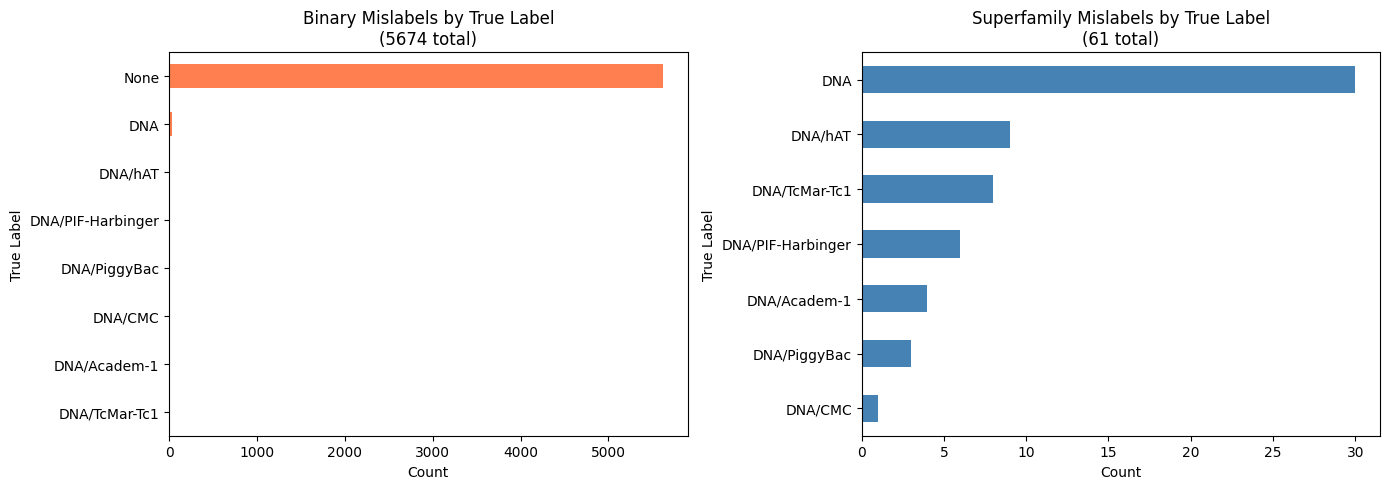

In [ ]:
# ============ Visualization: Mislabel Distribution ============

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary mislabels by true label (all 3 models wrong)
ax1 = axes[0]
bin_mislabel_by_true = binary_mislabels.groupby("true_label").size().sort_values(ascending=False).head(15)
bin_mislabel_by_true.plot(kind="barh", ax=ax1, color="coral")
ax1.set_xlabel("Count")
ax1.set_ylabel("True Label")
ax1.set_title(f"Binary Mislabels (All 3 Models Wrong)\n({len(binary_mislabels)} total)")
ax1.invert_yaxis()

# Superfamily mislabels by true label (all 3 models wrong)
ax2 = axes[1]
sf_mislabel_by_true = sf_mislabels.groupby("true_label").size().sort_values(ascending=False).head(15)
sf_mislabel_by_true.plot(kind="barh", ax=ax2, color="steelblue")
ax2.set_xlabel("Count")
ax2.set_ylabel("True Label")
ax2.set_title(f"Superfamily Mislabels (All 3 Models Wrong)\n({len(sf_mislabels)} total)")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("mislabel_distribution_all3.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============ Export Results ============

# Export all predictions
df.to_csv("all_predictions_v3_v4_v41.csv", index=False)
print(f"Saved all predictions to all_predictions_v3_v4_v41.csv")

# Export potential binary mislabels
binary_mislabels.to_csv("potential_binary_mislabels_all3.csv", index=False)
print(f"Saved {len(binary_mislabels)} potential binary mislabels to potential_binary_mislabels_all3.csv")

# Export potential superfamily mislabels
sf_mislabels.to_csv("potential_superfamily_mislabels_all3.csv", index=False)
print(f"Saved {len(sf_mislabels)} potential superfamily mislabels to potential_superfamily_mislabels_all3.csv")

# Export high-confidence mislabels (all 3 models agree on alternative)
high_conf_mislabels.to_csv("high_confidence_mislabels_all3.csv", index=False)
print(f"Saved {len(high_conf_mislabels)} high-confidence mislabels to high_confidence_mislabels_all3.csv")

Saved all predictions to all_predictions_v3_v4.csv
Saved 5674 potential binary mislabels to potential_binary_mislabels.csv
Saved 61 potential superfamily mislabels to potential_superfamily_mislabels.csv
Saved 27 high-confidence mislabels to high_confidence_mislabels.csv


In [ ]:
# ============ Confusion Matrix for High-Confidence Mislabels ============

if len(high_conf_mislabels) > 0:
    # Get unique labels involved
    involved_labels = set(high_conf_mislabels["true_label"]) | set(high_conf_mislabels["v41_sf_pred"])
    involved_labels = sorted(involved_labels)
    
    # Create confusion matrix (using v41 predictions as all 3 agree)
    confusion = pd.crosstab(
        high_conf_mislabels["true_label"], 
        high_conf_mislabels["v41_sf_pred"],
        margins=True
    )
    
    print("\nConfusion Matrix of High-Confidence Mislabels (All 3 models agree):")
    print("(Rows = True Label, Columns = Predicted Label by all 3)")
    print(confusion)


Confusion Matrix of High-Confidence Mislabels:
(Rows = True Label, Columns = Predicted Label)
v3_sf_pred         DNA  DNA/Academ-1  DNA/CMC  DNA/PIF-Harbinger  \
true_label                                                         
DNA                  0             1        1                  1   
DNA/Academ-1         0             0        0                  0   
DNA/CMC              0             1        0                  0   
DNA/PIF-Harbinger    3             0        0                  0   
DNA/PiggyBac         1             0        0                  0   
DNA/TcMar-Tc1        2             1        0                  0   
DNA/hAT              2             0        0                  1   
All                  8             3        1                  2   

v3_sf_pred         DNA/PiggyBac  DNA/hAT  All  
true_label                                     
DNA                           1        9   13  
DNA/Academ-1                  0        2    2  
DNA/CMC                       0 

In [ ]:
# ============ Final Summary ============

print("\n" + "="*70)
print("FINAL SUMMARY (V3, V4, V4.1)")
print("="*70)

print(f"\nTotal sequences analyzed: {len(df)}")

# Binary: modeled classes only
bin_df = df[df["binary_eval"]]
print(f"\n📊 Binary Classification (modeled classes only):")
print(f"   • Evaluated samples: {len(bin_df)} / {len(df)}")
print(f"   • All 3 models correct: {bin_df['all_bin_correct'].sum()}")
print(f"   • All 3 models WRONG: {bin_df['all_bin_wrong'].sum()} ⚠️")

# Superfamily: transposase+ with modeled superfamilies only
tpase_df = df[(df["true_binary"] == 1) & df["modeled_sf"]]
print(f"\n📊 Superfamily Classification (transposase+ with modeled superfamilies only):")
print(f"   • Total evaluated transposase+ samples: {len(tpase_df)}")
print(f"   • All 3 models WRONG: {len(sf_mislabels)} ⚠️")
print(f"   • All 3 models agree on alternative: {len(high_conf_mislabels)} ⚠️⚠️")

print(f"\n📁 Exported files:")
print(f"   • all_predictions_v3_v4_v41.csv")
print(f"   • potential_binary_mislabels_all3.csv")
print(f"   • potential_superfamily_mislabels_all3.csv")
print(f"   • high_confidence_mislabels_all3.csv")

print(f"\n🔍 Recommended next steps:")
print(f"   1. Review high_confidence_mislabels_all3.csv first (all 3 models agree on alternative)")
print(f"   2. Check if mislabel patterns match known biological relationships")
print(f"   3. Consider re-annotating sequences with consistent 3-model disagreement")


FINAL SUMMARY

Total sequences analyzed: 135751

📊 Binary Classification (modeled classes only):
   • Evaluated samples: 135353 / 135751
   • Both models correct: 118601
   • Both models WRONG: 5674 ⚠️

📊 Superfamily Classification (transposase+ with modeled superfamilies only):
   • Total evaluated transposase+ samples: 10255
   • Both models WRONG: 61 ⚠️
   • Both models agree on alternative: 27 ⚠️⚠️

📁 Exported files:
   • all_predictions_v3_v4.csv
   • potential_binary_mislabels.csv
   • potential_superfamily_mislabels.csv
   • high_confidence_mislabels.csv

🔍 Recommended next steps:
   1. Review high_confidence_mislabels.csv first (both models agree on alternative)
   2. Check if mislabel patterns match known biological relationships
   3. Consider re-annotating sequences with consistent model disagreement
